Melhor solução: 8 torres
Posições: [   0  411  852 1262 1700 2142 2587 3000]
Alturas de fixação: [35 35 28 35 30 35 35 29]
Tipos de torre: ['S' 'A' 'S' 'A' 'S' 'S' 'S' 'A']
Vãos: [411 440 410 437 441 445 412]
Custo Total: R$ 70,090,000


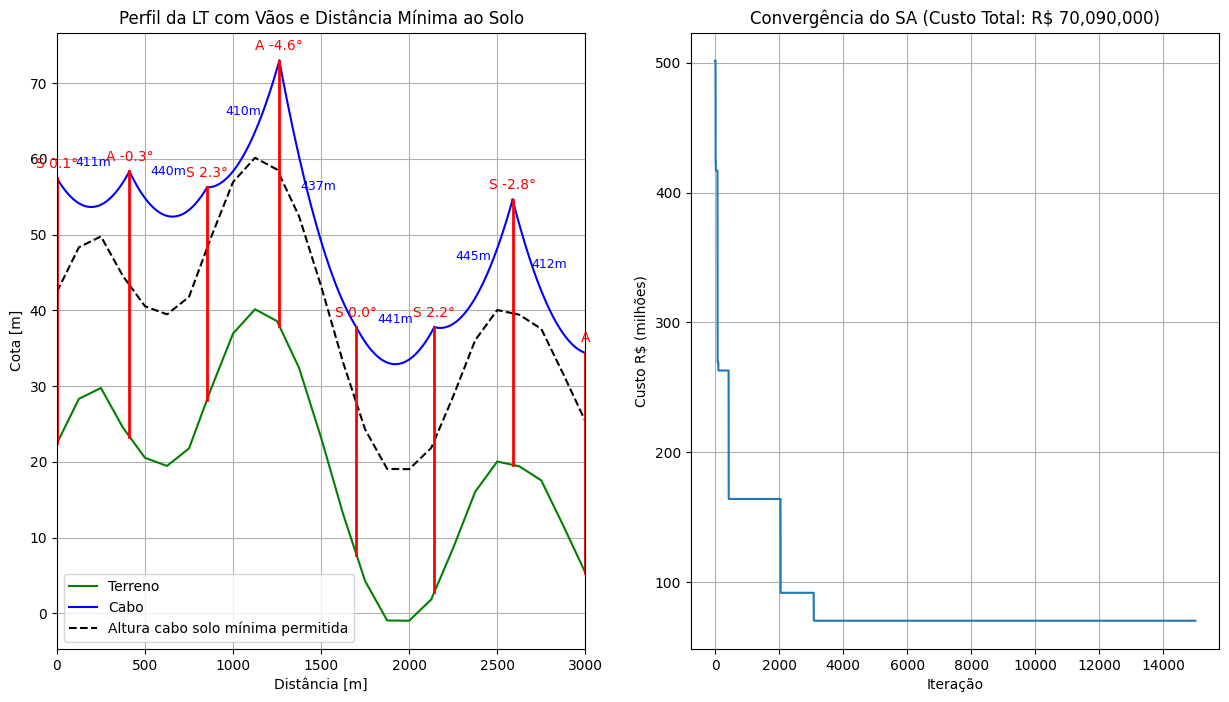

In [3]:
import numpy as np
import random
import math
import matplotlib.pyplot as plt

# 1. TERRENO + REGRAS
DIST_TOTAL = 3000 # 2km pra atravessar
MAX_VAO = 450 # m. Vão máximo mecânico
MIN_VAO = 350 # m. Vão mínimo (novo parâmetro)
CUSTO_TORRE_BASE = 150000 # R$
CUSTO_CABO_KM = 120000 # R$/km
PENALIDADE_ALTURA_QUADRATICA = 50_000 # R$/m^2, penalidade quadrática por metro extra acima da altura mínima (Adjusted further)
MIN_CABLE_GROUND_CLEARANCE = 20 # m, distância mínima do cabo ao solo (Increased to force higher towers)
PENALIDADE_EXCESSO_TORRES_POR_UNIDADE = 20_000_000 # Nova penalidade por cada torre a mais (New)

# Alturas de fixação do cabo na torre
H_TOWER_ATTACHMENT_DEFAULT = 30 # m
H_TOWER_ATTACHMENT_MIN = 20 # m
H_TOWER_ATTACHMENT_MAX = 35 # m (Reduced to encourage smaller towers)

# Penalidades
PENALIDADE_VAO_EXCEDIDO = 100_000_000 # Penalidade por vão exceder MAX_VAO (Increased significantly)
PENALIDADE_VAO_MINIMO = 100_000_000 # Nova penalidade por vão menor que MIN_VAO (Increased significantly)
PENALIDADE_GROUND_CLEARANCE = 100_000_000 # Penalidade por violação da distância mínima ao solo (Increased significantly)
CUSTO_TORRE_TIPO_A_EXTRA = 10000 # Custo extra para torres de ancoragem
MAX_ANGLE_DEGREES = 5 # Graus, ângulo máximo do cabo em relação à horizontal sem exigir torre A
PENALIDADE_ANGULO_EXCEDIDO = 5_000_000 # Penalidade por exceder o ângulo sem torre A (Reduced significantly)

# Parâmetros do cabo (para cálculo da catenária simplificada)
TENSION = 75000 # N (tensão horizontal do cabo) (Increased tension)
WEIGHT_PER_UNIT_LENGTH = 15 # N/m (peso do cabo por metro)

# Número de iterações para o Simulated Annealing
NUM_ITERATIONS = 15000

# Perfil do terreno: mais irregular (reverted to original more irregular setup)
x_terreno = np.linspace(0, DIST_TOTAL, 25) # Alterado de 200 para 50

# Combinação de múltiplas ondas senoidais e ruído para um terreno mais suave (adjusted for user request)
# Aumentando a complexidade do terreno
y_terreno_raw = 20 + 15 * np.sin(x_terreno / 500) + \
            20 * np.cos(x_terreno / 200) + \
            np.random.normal(0, 5, size=len(x_terreno)) # Base com ondas mais agressivas e menor ruído (sd reduzido)

# Aplicar um filtro de média móvel para suavizar os picos
window_size = 5 # Tamanho da janela para a média móvel
kernel = np.ones(window_size) / window_size
y_terreno = np.convolve(y_terreno_raw, kernel, mode='same')

# Função para calcular a flecha (aproximação parabólica da catenária)
def calcular_flecha(vao, tension=TENSION, weight=WEIGHT_PER_UNIT_LENGTH):
    """Calcula a flecha de um cabo, aproximação parabólica da catenária."""
    # w * L^2 / (8 * T)
    return (weight * vao**2) / (8 * tension)

def calcular_perfil_cabo(x_start, y_attach_start, x_end, y_attach_end, num_points=100):
    """
    Calcula o perfil parabólico de um segmento de cabo entre dois pontos de fixação.
    Retorna os pontos x e y do cabo.
    """
    vao = x_end - x_start

    # Handle zero vao to prevent division by zero errors
    if vao == 0:
        return np.array([x_start]), np.array([y_attach_start])

    # Coordenadas relativas
    y_rel_start = 0
    y_rel_end = y_attach_end - y_attach_start


    # Alturas de fixação acima do ponto mais baixo da parábola
    h1 = y_attach_start
    h2 = y_attach_end

    # Vão horizontal
    L = vao

    # Flecha calculada para o vão
    f = calcular_flecha(L)

    # Coordenada x do ponto mais baixo da parábola (relativo a x_start)
    x_low_point = (L/2) - (TENSION * (h2-h1)) / (WEIGHT_PER_UNIT_LENGTH * L)

    x_cable_segment = np.linspace(x_start, x_end, num_points)
    y_cable_segment = np.zeros_like(x_cable_segment)

    for j, x_val in enumerate(x_cable_segment):
        x_rel = x_val - x_start
        # Equação da parábola para o cabo
        y_cable_segment[j] = h1 + (WEIGHT_PER_UNIT_LENGTH / (2 * TENSION)) * (x_rel**2 - L*x_rel) + (x_rel/L) * (h2 - h1)

    return x_cable_segment, y_cable_segment

def custo_solucao(posicoes_torres, y_attachment_points, tipos_torres, n_torres_inicial_sa=20): # Adiciona n_torres_inicial_sa como parâmetro
    custo = 0
    penalidade = 0
    vaos = np.diff(posicoes_torres)

    # Penalidade por excesso de torres (agora quadrática)
    if len(posicoes_torres) > n_torres_inicial_sa:
        penalidade += (len(posicoes_torres) - n_torres_inicial_sa)**2 * PENALIDADE_EXCESSO_TORRES_POR_UNIDADE

    # Custo das torres
    custo += len(posicoes_torres) * CUSTO_TORRE_BASE
    for i, h in enumerate(y_attachment_points):
        # Changed to penalize heights above MIN, quadratically
        if h > H_TOWER_ATTACHMENT_MIN:
            penalidade += (h - H_TOWER_ATTACHMENT_MIN)**2 * PENALIDADE_ALTURA_QUADRATICA
        if tipos_torres[i] == 'A': # Adiciona custo extra para torres de ancoragem
            custo += CUSTO_TORRE_TIPO_A_EXTRA

    # Custo do cabo
    custo += DIST_TOTAL/1000 * CUSTO_CABO_KM

    for i in range(len(vaos)): # Ajustar o loop para considerar torres de 0 a n-1
        vao = vaos[i]

        # Rígida restrição: se o vão for menor ou igual a 0 ou menor que MIN_VAO, invalida a solução.
        if vao < MIN_VAO:
            return float('inf'), None # Invalida a solução imediatamente

        # Rígida restrição: se o vão exceder o MAX_VAO, invalida a solução.
        if vao > MAX_VAO:
            return float('inf'), None # Invalida a solução imediatamente

        # Penalidade por vão exceder o máximo (essa linha será removida se a condição acima for acionada)
        # if vao > MAX_VAO:
        #    penalidade += PENALIDADE_VAO_EXCEDIDO

        # Calcular perfil do cabo e verificar distância ao solo
        x_start = posicoes_torres[i]
        y_attach_start_on_tower = y_attachment_points[i]
        x_end = posicoes_torres[i+1]
        y_attach_end_on_tower = y_attachment_points[i+1]

        # Altura do terreno nos pontos da torre
        y_terreno_start = np.interp(x_start, x_terreno, y_terreno)
        y_terreno_end = np.interp(x_end, x_terreno, y_terreno)

        # Altura de fixação do cabo no espaço absoluto (terreno + altura da torre)
        y_attach_start_abs = y_attach_start_on_tower + y_terreno_start
        y_attach_end_abs = y_attach_end_on_tower + y_terreno_end

        x_cable_segment, y_cable_segment = calcular_perfil_cabo(x_start, y_attach_start_abs, x_end, y_attach_end_abs)

        # Interpolar o perfil do terreno para os mesmos pontos do cabo
        y_terreno_segment = np.interp(x_cable_segment, x_terreno, y_terreno)

        # Verificar distância mínima ao solo
        if np.any(y_cable_segment - y_terreno_segment < MIN_CABLE_GROUND_CLEARANCE):
            penalidade += PENALIDADE_GROUND_CLEARANCE

        # Verificar restrição de ângulo
        delta_y = y_attach_end_abs - y_attach_start_abs
        delta_x = x_end - x_start
        angle_degrees = np.abs(np.degrees(np.arctan2(delta_y, delta_x)))

        if angle_degrees > MAX_ANGLE_DEGREES:
            # Ambas as torres do segmento precisam ser tipo 'A' se o ângulo for excedido
            if tipos_torres[i] == 'S':
                penalidade += PENALIDADE_ANGULO_EXCEDIDO
            if tipos_torres[i+1] == 'S':
                penalidade += PENALIDADE_ANGULO_EXCEDIDO

    return custo + penalidade, vaos


# 2. SIMULATED ANNEALING
def sa_lt(dist_total, n_torres_inicial=8, num_iterations=NUM_ITERATIONS): # Alterado para 8 para vãos iniciais dentro do MAX_VAO
    # Começa com torres igualmente espaçadas
    pos = np.linspace(0, dist_total, n_torres_inicial)
    # Alturas de fixação iniciais
    h_attach = np.array([H_TOWER_ATTACHMENT_MIN] * n_torres_inicial) # Initialized to MIN
    # Tipos de torre iniciais (apenas suspensão para começar)
    tipos = np.array(['S'] * n_torres_inicial, dtype=str)

    melhor_pos = pos.copy()
    melhor_h_attach = h_attach.copy()
    melhor_tipos = tipos.copy()
    melhor_custo, _ = custo_solucao(pos, h_attach, tipos, n_torres_inicial_sa=n_torres_inicial)

    # Aumentar a temperatura inicial e o número de iterações para maior exploração
    temp = 1_000_000_000.0 # Temperatura inicial aumentada drasticamente
    historia = [melhor_custo]

    for i_iter in range(num_iterations): # Número de iterações ajustado para 10.000
        # Gera vizinho: pode ser mover torre, mudar altura ou mudar tipo
        nova_pos = pos.copy()
        nova_h_attach = h_attach.copy()
        nova_tipos = tipos.copy()

        change_choice = random.random()

        if change_choice < 0.3: # Mover torre (probabilidade ajustada)
            idx = random.randint(1, len(nova_pos)-2) # não mexe na 1a e ultima
            nova_pos[idx] += random.uniform(-500, 500) # Perturbação aumentada para +/- 500m
            nova_pos = np.sort(nova_pos) # mantém ordem
            nova_pos = np.clip(nova_pos, 0, dist_total) # Ensure towers stay within bounds
        elif change_choice < 0.6: # Mudar altura de fixação (probabilidade ajustada)
            idx = random.randint(0, len(nova_h_attach)-1)
            nova_h_attach[idx] += random.uniform(-100, 100) # Perturbação aumentada para +/- 100m
            # Garante que a altura de fixação está dentro dos limites
            nova_h_attach[idx] = max(H_TOWER_ATTACHMENT_MIN, min(H_TOWER_ATTACHMENT_MAX, nova_h_attach[idx]))
        else: # Mudar tipo de torre (probabilidade aumentada)
            idx = random.randint(0, len(nova_tipos)-1)
            nova_tipos[idx] = 'A' if nova_tipos[idx] == 'S' else 'S' # Alterna entre S e A

        custo_atual, _ = custo_solucao(pos, h_attach, tipos, n_torres_inicial_sa=n_torres_inicial)
        custo_novo, _ = custo_solucao(nova_pos, nova_h_attach, nova_tipos, n_torres_inicial_sa=n_torres_inicial)
        delta = custo_novo - custo_atual

        if delta < 0 or random.random() < math.exp(-delta/temp):
            pos = nova_pos
            h_attach = nova_h_attach
            tipos = nova_tipos
            if custo_novo < melhor_custo:
                melhor_custo = custo_novo
                melhor_pos = pos.copy()
                melhor_h_attach = h_attach.copy()
                melhor_tipos = tipos.copy()

        historia.append(melhor_custo)
        temp *= 0.9999 # Taxa de resfriamento ajustada para 0.9999

    return melhor_pos, melhor_h_attach, melhor_tipos, melhor_custo, historia

# 3. RODAR E PLOTAR
melhor_pos, melhor_h_attach, melhor_tipos, custo_final, hist = sa_lt(DIST_TOTAL, num_iterations=NUM_ITERATIONS)

print(f"Melhor solução: {len(melhor_pos)} torres")
print(f"Posições: {melhor_pos.astype(int)}")
print(f"Alturas de fixação: {melhor_h_attach.astype(int)}")
print(f"Tipos de torre: {melhor_tipos}")
vaos_melhor_solucao = np.diff(melhor_pos).astype(int)
print(f"Vãos: {vaos_melhor_solucao}")
print(f"Custo Total: R$ {custo_final:,.0f}")

plt.figure(figsize=(15,8))
plt.subplot(1,2,1)
plt.plot(x_terreno, y_terreno, 'g-', label='Terreno')

# Plotar o perfil do cabo e a distância mínima ao solo
for i in range(len(melhor_pos) - 1):
    x_start = melhor_pos[i]
    y_attach_start_on_tower = melhor_h_attach[i]
    x_end = melhor_pos[i+1]
    y_attach_end_on_tower = melhor_h_attach[i+1]

    # Altura do terreno nos pontos da torre
    y_terreno_start = np.interp(x_start, x_terreno, y_terreno)
    y_terreno_end = np.interp(x_end, x_terreno, y_terreno)

    # Altura de fixação do cabo no espaço absoluto (terreno + altura da torre)
    y_attach_start_abs = y_attach_start_on_tower + y_terreno_start
    y_attach_end_abs = y_attach_end_on_tower + y_terreno_end

    x_cable_segment, y_cable_segment = calcular_perfil_cabo(x_start, y_attach_start_abs, x_end, y_attach_end_abs)
    plt.plot(x_cable_segment, y_cable_segment, 'b-', label='Cabo' if i==0 else "")

    # Plotar a linha da distância mínima ao solo
    y_terreno_segment = np.interp(x_cable_segment, x_terreno, y_terreno)
    plt.plot(x_cable_segment, y_terreno_segment + MIN_CABLE_GROUND_CLEARANCE, 'k--', label='Altura cabo solo mínima permitida' if i==0 else "")

    # Adicionar o valor do vão no meio do vão
    mid_x = (x_start + x_end) / 2
    # Find the corresponding y-value on the cable or just above the terrain
    mid_y_cable = np.interp(mid_x, x_cable_segment, y_cable_segment)
    mid_y_terrain = np.interp(mid_x, x_terreno, y_terreno)
    text_y_position = max(mid_y_cable, mid_y_terrain + MIN_CABLE_GROUND_CLEARANCE) + 5 # Place slightly above the cable or min clearance line
    plt.text(mid_x, text_y_position, f'{vaos_melhor_solucao[i]}m', color='blue', fontsize=9, ha='center', va='bottom')

# Plotar as torres
for i, p in enumerate(melhor_pos):
    # Altura base da torre no terreno
    y_terreno_at_tower = np.interp(p, x_terreno, y_terreno)
    # A torre vai do terreno até o ponto de fixação do cabo
    plt.plot([p, p], [y_terreno_at_tower, y_terreno_at_tower + melhor_h_attach[i]], 'r-', lw=2)

    tower_label = melhor_tipos[i]
    angle_text = ''
    # Calculate angle for the outgoing segment, if it's not the last tower
    if i < len(melhor_pos) - 1:
        x_start_segment = melhor_pos[i]
        y_attach_start_on_tower_segment = melhor_h_attach[i]
        x_end_segment = melhor_pos[i+1]
        y_attach_end_on_tower_segment = melhor_h_attach[i+1]

        y_terreno_start_segment = np.interp(x_start_segment, x_terreno, y_terreno)
        y_terreno_end_segment = np.interp(x_end_segment, x_terreno, y_terreno)

        y_attach_start_abs_segment = y_attach_start_on_tower_segment + y_terreno_start_segment
        y_attach_end_abs_segment = y_attach_end_on_tower_segment + y_terreno_end_segment

        delta_y_segment = y_attach_end_abs_segment - y_attach_start_abs_segment
        delta_x_segment = x_end_segment - x_start_segment
        angle_degrees_segment = np.degrees(np.arctan2(delta_y_segment, delta_x_segment))
        angle_text = f' {angle_degrees_segment:.1f}°' # Add a space for separation
    # Adicionar marcador para o tipo de torre e o ângulo
    plt.text(p, y_terreno_at_tower + melhor_h_attach[i] + 1,
             f'{tower_label}{angle_text}', color='red', fontsize=10, ha='center', va='bottom')

plt.title("Perfil da LT com Vãos e Distância Mínima ao Solo")
plt.xlabel("Distância [m]"); plt.ylabel("Cota [m]")
plt.legend()
plt.grid(True)
plt.xlim(0, DIST_TOTAL)


plt.subplot(1,2,2)
plt.plot(np.array(hist) / 1_000_000) # Custo em milhões
plt.title(f"Convergência do SA (Custo Total: R$ {custo_final:,.0f})") # Adicionado custo total ao título
plt.xlabel("Iteração"); plt.ylabel("Custo R$ (milhões)") # Rótulo ajustado
plt.grid(True)
plt.show()